# Robust Ground Truth Labeling for SPIRAL2 LLRF Postmortem Files

**Author**: SPIRAL2 Anomaly Detection Team  
**Date**: February 2026  
**Status**: New analysis — does NOT modify any existing pipeline outputs

---

## Motivation

The `ALM` field in postmortem file headers **cannot be trusted** as ground truth labels for supervised machine learning.

### Evidence from `VérificationALM.odt`

Three labeling methods were compared on 2497 quality-filtered files:

| Method | Description |
|--------|-------------|
| **ALM header** | Single value captured when file header is written (after trigger) |
| **Last time** | Fault signal active at the very last sample of the file |
| **Any time after t0** | Fault signal active at *any* sample after the trigger |

| Comparison | Disagreement | Percentage |
|------------|-------------|------------|
| ALM vs Last time | 266 | 10.65% |
| ALM vs Any time after t0 | 957 | **38.33%** |

**Key finding**: 966 files have `ALM=0` (no fault declared) but contain visible fault events in their waveforms.
Only 2 files show the opposite (ALM says fault but waveform disagrees).

### Root Cause (from `logiciel_LLRF_3.5.pdf`, §4.4)

The `RF_ALARM` register works in **inverse logic** (0=alarm). Faults should be latched until acknowledged via `RSAL` (reset alarms). However, the `RF_CMD_RESET_ALARM` bit **"rafraîchit"** (refreshes) the register to its current state — not just clears it. If a transient fault occurs then disappears before the file header is written, `ALM=0` is recorded even though the fault occurred during acquisition.

The time-series `Défauts` column in the acquisition buffer captures the `RF_ALARM` register state at **every sample** during the circular buffer recording — making it far more reliable than the single header-captured value.

### Signal-Level Fault Trigger Equations

From §3.3.11 and §4.4 of the LLRF documentation:

**WRN (software warnings, no RF cutoff):**
- D0: `UCRA > UCRT` — Ucr amplitude alert  
- D1: `PKUI > PKTS` — pick-up current alert (µA)  
- D2: `|UCAM − AMPS| > AMPT × 80%` OR `|UCPH − PHIS| > PHIT × 80%` — regulation warning

**ALM (FPGA hardware alarms, cause immediate RF cutoff):**
- D1 `PKUP`: `PKUI > PKTH` (hardware comparator, threshold = read-only hardware voltage)  
- D2 `AUTH_SPR`: SPR authorization signal = 0 (radiation protection interlock)  
- D3 `AUTH_RF`: RF authorization signal = 0 (machine protection interlock)  
- D4–D6: Pick-up card hardware failures (power supply, threshold voltage, antenna bias)  
- D7 `REGUL`: `UCAM ∉ [AMPT_min, AMPT_max]` OR `UCPH ∉ [PHIT_min, PHIT_max]`  
- D8 `FAST`: External fast cutoff digital input

### Strategy

We use the **"Any time after t0"** method on the PyPostMortem `df_defaut` time-series:
- `compute_defauts=True` in `Read_Signals` activates decoding of the per-sample `Défauts` column
- `df_defaut` returns a DataFrame with 7 fault columns, values 0 or 1 (already decoded from inverse logic)
- New label = `any(df_defaut.iloc[POSTROW:] == 1)` — any fault active after trigger

This notebook processes all **14,232 raw postmortem files**, compares new vs. old labels, and saves new ground truth labels without modifying any existing pipeline outputs.

---
## Section 1 — Setup

In [24]:
import sys
import os
import signal
import warnings
import pickle
import glob
import time
from pathlib import Path
from datetime import datetime
from multiprocessing import Pool, cpu_count
from functools import partial

import numpy as np
import pandas as pd
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

warnings.filterwarnings('ignore')

# ─── Paths ────────────────────────────────────────────────────────────────────
PYPM_PATH = Path('/pbs/throng/m4cast/projects/SPIRAL2/programmes/PyPostMortem/src')
RAW_DATA_DIR  = Path('/sps/m4cast/_spiral2_data/_llrf_data/raw_data')
COOKED_DATA_DIR = Path('/sps/m4cast/_spiral2_data/_llrf_data/cooked_data')

# Output directory (new — does NOT overwrite existing outputs)
NOTEBOOK_DIR = Path('/pbs/throng/m4cast/projects/SPIRAL2/anomalies/anomalies_exploration/analysis')
OUTPUT_DIR = NOTEBOOK_DIR / 'outputs' / 'preprocessing'
CHECKPOINT_DIR = OUTPUT_DIR / 'checkpoints'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

# ─── PyPostMortem ─────────────────────────────────────────────────────────────
if str(PYPM_PATH) not in sys.path:
    sys.path.insert(0, str(PYPM_PATH))

from PyPostmortem.utils.PyPostMortem import Read_Signals
print(f'PyPostMortem loaded from: {PYPM_PATH}')

# ─── Processing config ────────────────────────────────────────────────────────
CONFIG = {
    'n_workers': max(1, cpu_count() - 2),  # Leave 2 cores free
    'file_timeout': 30,                    # seconds per file
    'checkpoint_every': 500,               # files between checkpoints
    'quality_filters': {
        'min_kpi':  10.0,
        'min_ucav': 0.1,
        'min_uci':  0.02,
    },
}

# ─── Fault column definitions (from PyPostMortem df_defaut) ───────────────────
DEFAUT_COLS = [
    'Seuil pick-up',               # bit 0
    'Coupure externe rapide',       # bit 1
    'Absence autorisation RF',      # bit 2
    'Seuil de vide',                # bit 3
    'Claquage ou quench cavité',    # bit 4
    'Dép seuil de sécurité RF',     # bit 5
    'Rég signal RF hors tolérance', # bit 6
]

# Short names for plots
DEFAUT_SHORT = [
    'PKUP', 'FAST', 'AUTH_RF', 'VACUUM', 'QUENCH', 'RF_SAFETY', 'REGUL'
]

print(f'Output directory: {OUTPUT_DIR}')
print(f'Workers: {CONFIG["n_workers"]}')
print(f'Raw data files to process: checking...')
all_raw_files = sorted(RAW_DATA_DIR.rglob('*'))
all_raw_files = [f for f in all_raw_files if f.is_file()]
print(f'Total raw files found: {len(all_raw_files)}')

PyPostMortem loaded from: /pbs/throng/m4cast/projects/SPIRAL2/programmes/PyPostMortem/src
Output directory: /pbs/throng/m4cast/projects/SPIRAL2/anomalies/anomalies_exploration/analysis/outputs/preprocessing
Workers: 30
Raw data files to process: checking...
Total raw files found: 14232


---
## Section 2 — API Demonstration on a Single File

We load one postmortem file and show both the old (header ALM) and new (waveform df_defaut) labeling approaches side by side.

In [25]:
# ─── Load a known test file ────────────────────────────────────────────────────
# This file has ALM=0x0001 (Seuil pick-up fault)
TEST_FILE = Path('/sps/m4cast/_spiral2_data/_llrf_data/raw_data/2019/CMA/CMA02/2019 11 20 CMA02_0003')
assert TEST_FILE.exists(), f'Test file not found: {TEST_FILE}'

with open(TEST_FILE, 'rb') as f:
    content = f.read()

# ─── Old approach: header ALM only ────────────────────────────────────────────
params_old, _, df_signals_old, _, _, _ = Read_Signals(
    content, compute_defauts=False, compute_etats=False,
    plot_signaux=False, show_header=False
)

# Parse metadata
metadata = {}
for key, val_dict in params_old.items():
    metadata[key] = val_dict['Valeur'] if isinstance(val_dict, dict) and 'Valeur' in val_dict else val_dict

alm_raw = metadata.get('ALM', '0x0000')
alm_val  = int(alm_raw, 16) if isinstance(alm_raw, str) else int(alm_raw)
old_fault_bits = [(alm_val >> i) & 1 for i in range(7)]

print('═'*60)
print('OLD LABELING (header ALM)')
print('═'*60)
print(f'  ALM raw value : {alm_raw}')
print(f'  ALM integer   : {alm_val} (binary: {bin(alm_val)})')
print(f'  Binary label  : {int(alm_val > 0)} (fault={alm_val > 0})')
print(f'  Per-fault bits:')
for name, bit in zip(DEFAUT_COLS, old_fault_bits):
    print(f'    [{bit}]  {name}')

print(f'\n  POSTROW (trigger index): {metadata.get("POSTROW", "?")}  (t0)')
print(f'  NROW  (total samples)  : {metadata.get("NROW", "?")}')  
print(f'  NDEC  (decimation)     : {metadata.get("NDEC", "?")}')  
print(f'  KPI                    : {metadata.get("KPI", "?")} dB')

════════════════════════════════════════════════════════════
OLD LABELING (header ALM)
════════════════════════════════════════════════════════════
  ALM raw value : 0x0001
  ALM integer   : 1 (binary: 0b1)
  Binary label  : 1 (fault=True)
  Per-fault bits:
    [1]  Seuil pick-up
    [0]  Coupure externe rapide
    [0]  Absence autorisation RF
    [0]  Seuil de vide
    [0]  Claquage ou quench cavité
    [0]  Dép seuil de sécurité RF
    [0]  Rég signal RF hors tolérance

  POSTROW (trigger index): 50048  (t0)
  NROW  (total samples)  : 100096
  NDEC  (decimation)     : 200
  KPI                    : 35.000000 dB


In [26]:
# ─── New approach: waveform df_defaut ─────────────────────────────────────────
params_new, time_vec, df_signals, df_defaut, _, _ = Read_Signals(
    content, compute_defauts=True, compute_etats=False,
    plot_signaux=False, show_header=False
)

postrow = int(metadata.get('POSTROW', 50048))
nrow    = int(metadata.get('NROW', 100096))

print('═'*60)
print('NEW LABELING (waveform df_defaut — Any time after t0)')
print('═'*60)
print(f'  df_defaut shape: {df_defaut.shape}')
print(f'  df_defaut columns: {list(df_defaut.columns)}')
print(f'  Values in df_defaut: {sorted(df_defaut.values.flatten().unique() if hasattr(df_defaut.values.flatten(), "unique") else set(df_defaut.values.flatten()))}')
print()

faults_after_t0 = df_defaut.iloc[postrow:]
new_binary      = faults_after_t0.any().any()
new_fault_bits  = faults_after_t0.any().values.astype(int)

print(f'  Samples after t0 (POSTROW={postrow}): {len(faults_after_t0)}')
print(f'  Binary label: {int(new_binary)} (fault={new_binary})')
print(f'  Per-fault waveform activity after t0:')
for name, bit, old_bit in zip(DEFAUT_COLS, new_fault_bits, old_fault_bits):
    match = '✓' if bit == old_bit else '✗ MISMATCH'
    print(f'    [{bit}]  {name}  {match}')

print(f'\n  Label agreement (old vs new binary): {old_fault_bits[0] == int(new_binary)}')

════════════════════════════════════════════════════════════
NEW LABELING (waveform df_defaut — Any time after t0)
════════════════════════════════════════════════════════════
  df_defaut shape: (100096, 7)
  df_defaut columns: ['Seuil pick-up', 'Coupure externe rapide', 'Absence autorisation RF', 'Seuil de vide', 'Claquage ou quench cavité', 'Dép seuil de sécurité RF', 'Rég signal RF hors tolérance']
  Values in df_defaut: [0, 1]

  Samples after t0 (POSTROW=50048): 50048
  Binary label: 1 (fault=True)
  Per-fault waveform activity after t0:
    [1]  Seuil pick-up  ✓
    [1]  Coupure externe rapide  ✗ MISMATCH
    [1]  Absence autorisation RF  ✗ MISMATCH
    [1]  Seuil de vide  ✗ MISMATCH
    [1]  Claquage ou quench cavité  ✗ MISMATCH
    [1]  Dép seuil de sécurité RF  ✗ MISMATCH
    [1]  Rég signal RF hors tolérance  ✗ MISMATCH

  Label agreement (old vs new binary): True


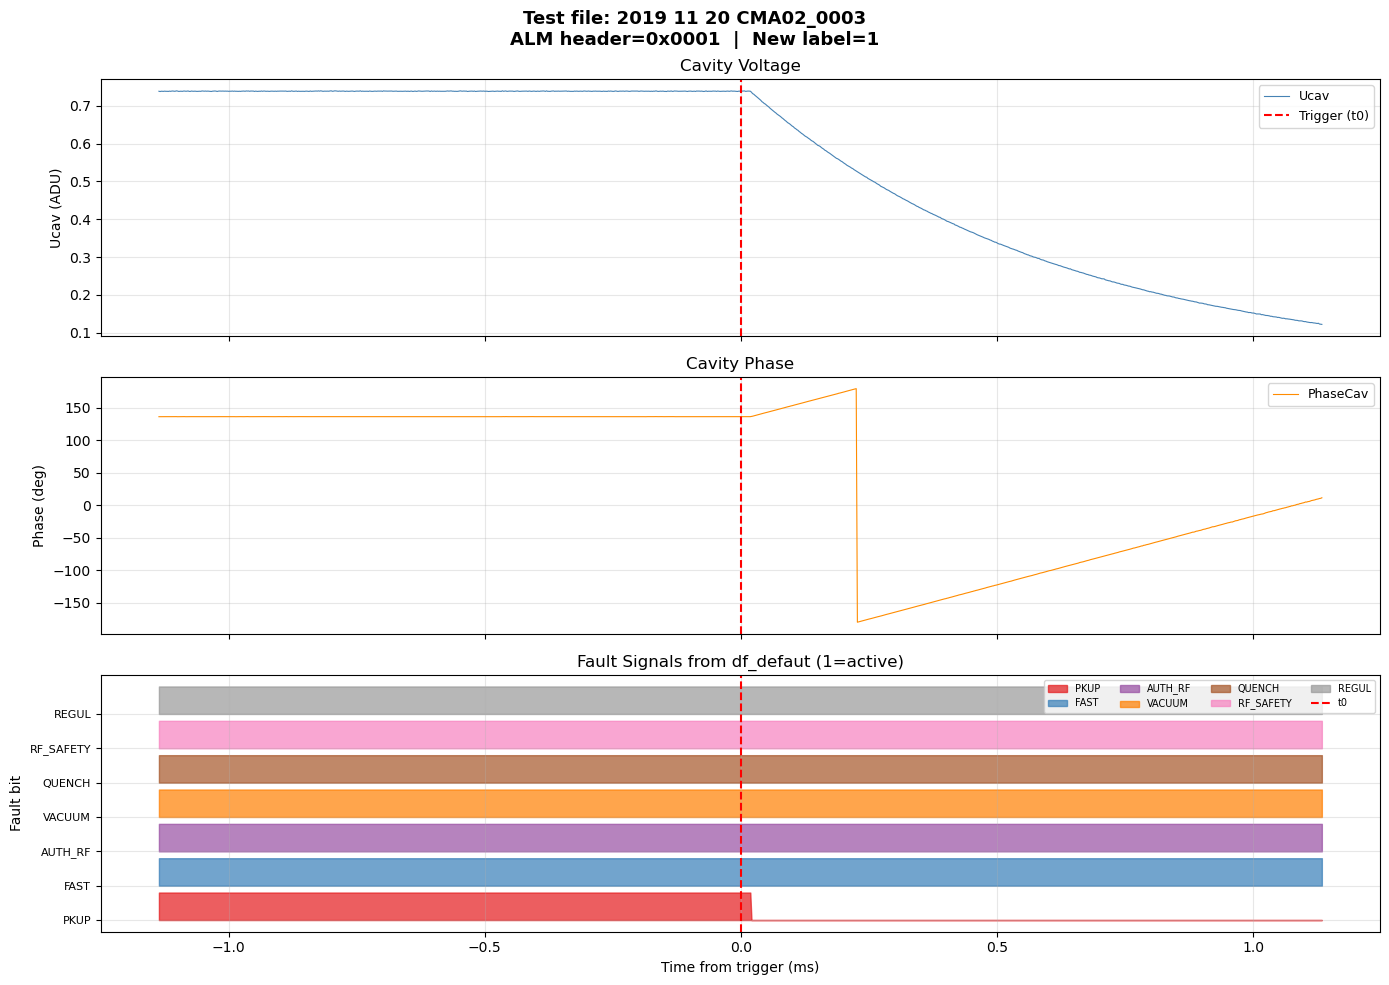

Plot saved to /pbs/throng/m4cast/projects/SPIRAL2/anomalies/anomalies_exploration/analysis/outputs/preprocessing/demo_single_file_fault_signals.png


In [27]:
# ─── Visualize fault time-series around trigger ────────────────────────────────
ndec = int(metadata.get('NDEC', 200))
fs = 88e6 / ndec  # Effective sampling rate after decimation

# Window: 500 samples before and 500 after t0
win_pre  = 500
win_post = 500
idx_start = max(0, postrow - win_pre)
idx_end   = min(nrow, postrow + win_post)

t_ms = (np.arange(idx_start, idx_end) - postrow) / fs * 1000  # milliseconds from trigger

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
fig.suptitle(f'Test file: {TEST_FILE.name}\nALM header={alm_raw}  |  New label={int(new_binary)}',
             fontsize=13, fontweight='bold')

# Panel 1: Ucav amplitude
ax = axes[0]
if 'Ucav' in df_signals.columns:
    ucav = df_signals['Ucav'].values[idx_start:idx_end]
    ax.plot(t_ms, ucav, color='steelblue', lw=0.8, label='Ucav')
ax.axvline(0, color='red', ls='--', lw=1.5, label='Trigger (t0)')
ax.set_ylabel('Ucav (ADU)')
ax.legend(loc='upper right', fontsize=9)
ax.set_title('Cavity Voltage')
ax.grid(True, alpha=0.3)

# Panel 2: PhaseCav
ax = axes[1]
if 'PhaseCav' in df_signals.columns:
    phase = df_signals['PhaseCav'].values[idx_start:idx_end]
    ax.plot(t_ms, phase, color='darkorange', lw=0.8, label='PhaseCav')
ax.axvline(0, color='red', ls='--', lw=1.5)
ax.set_ylabel('Phase (deg)')
ax.legend(loc='upper right', fontsize=9)
ax.set_title('Cavity Phase')
ax.grid(True, alpha=0.3)

# Panel 3: Fault bits (stacked)
ax = axes[2]
colors = plt.cm.Set1(np.linspace(0, 1, 7))
for i, (col, short) in enumerate(zip(DEFAUT_COLS, DEFAUT_SHORT)):
    if col in df_defaut.columns:
        fault_ts = df_defaut[col].values[idx_start:idx_end].astype(float)
        # Offset each fault line for readability
        ax.fill_between(t_ms, i + fault_ts * 0.8, i, alpha=0.7,
                         color=colors[i], label=short)
ax.axvline(0, color='red', ls='--', lw=1.5, label='t0')
ax.set_yticks(range(7))
ax.set_yticklabels(DEFAUT_SHORT, fontsize=8)
ax.set_ylabel('Fault bit')
ax.set_xlabel('Time from trigger (ms)')
ax.set_title('Fault Signals from df_defaut (1=active)')
ax.legend(loc='upper right', fontsize=7, ncol=4)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'demo_single_file_fault_signals.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Plot saved to {OUTPUT_DIR / "demo_single_file_fault_signals.png"}')

---
## Section 3 — Old Labeling Logic (Documentation)

We load the existing processed data to understand what the old labels look like.

In [28]:
# ─── Load existing processed data (old labels) ────────────────────────────────
features_pkl = COOKED_DATA_DIR / 'features_engineered.pkl'
print(f'Loading existing processed data: {features_pkl}')

with open(features_pkl, 'rb') as f:
    existing_data = pickle.load(f)

df_meta_old = pd.DataFrame(existing_data['metadata']) if isinstance(existing_data['metadata'], list) else existing_data['metadata']
y_binary_old    = existing_data['y_binary']     # (N,) 0 or 1
y_multilabel_old = existing_data['y_multilabel'] # (N, 7)
fault_col_names_old = existing_data['fault_column_names']

print(f'Total events in existing data: {len(df_meta_old)}')
print(f'Binary label distribution: normal={np.sum(y_binary_old==0)}, fault={np.sum(y_binary_old==1)}')
print(f'Fault column names (old): {fault_col_names_old}')
print(f'\nOld labeling code (from prepare_data_cluster.py):')
print('''
def extract_fault_labels(metadata):
    alm_raw = metadata.get('ALM', 0)
    alm = int(alm_raw, 16) if isinstance(alm_raw, str) else int(alm_raw)
    has_fault = alm > 0
    fault_bits = [(alm >> i) & 1 for i in range(7)]
    return {'binary': int(has_fault), 'multilabel': fault_bits, 'alm_value': alm}
''')

Loading existing processed data: /sps/m4cast/_spiral2_data/_llrf_data/cooked_data/features_engineered.pkl
Total events in existing data: 4509
Binary label distribution: normal=3324, fault=1185
Fault column names (old): ['Pickup threshold', 'Fast external cutoff', 'RF authorization absent', 'Vacuum threshold', 'Cavity quench/breakdown', 'RF safety threshold exceeded', 'RF regulation out of tolerance']

Old labeling code (from prepare_data_cluster.py):

def extract_fault_labels(metadata):
    alm_raw = metadata.get('ALM', 0)
    alm = int(alm_raw, 16) if isinstance(alm_raw, str) else int(alm_raw)
    has_fault = alm > 0
    fault_bits = [(alm >> i) & 1 for i in range(7)]
    return {'binary': int(has_fault), 'multilabel': fault_bits, 'alm_value': alm}



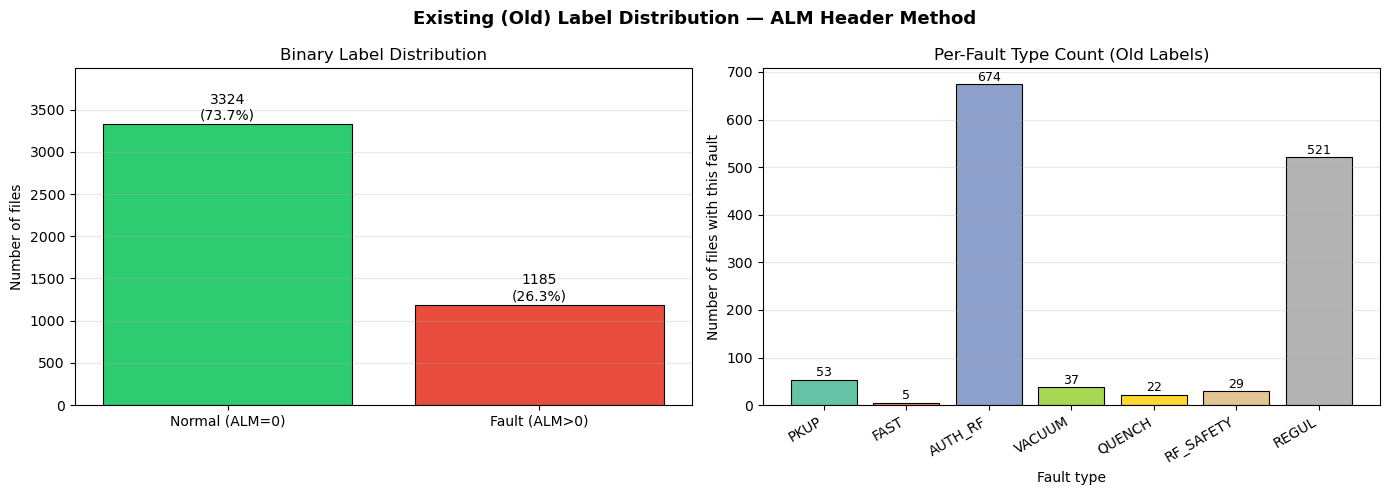

Plot saved.


In [29]:
# ─── Visualize old label distribution ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Existing (Old) Label Distribution — ALM Header Method', fontsize=13, fontweight='bold')

# Binary distribution
ax = axes[0]
n_normal = np.sum(y_binary_old == 0)
n_fault  = np.sum(y_binary_old == 1)
bars = ax.bar(['Normal (ALM=0)', 'Fault (ALM>0)'], [n_normal, n_fault],
               color=['#2ecc71', '#e74c3c'], edgecolor='black', linewidth=0.8)
for bar, val in zip(bars, [n_normal, n_fault]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             f'{val}\n({val/len(y_binary_old)*100:.1f}%)',
             ha='center', va='bottom', fontsize=10)
ax.set_title('Binary Label Distribution')
ax.set_ylabel('Number of files')
ax.set_ylim(0, max(n_normal, n_fault) * 1.2)
ax.grid(True, axis='y', alpha=0.3)

# Per-fault type distribution
ax = axes[1]
fault_counts_old = y_multilabel_old.sum(axis=0)
colors = plt.cm.Set2(np.linspace(0, 1, 7))
bars = ax.bar(DEFAUT_SHORT, fault_counts_old, color=colors, edgecolor='black', linewidth=0.8)
for bar, val in zip(bars, fault_counts_old):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             str(int(val)), ha='center', va='bottom', fontsize=9)
ax.set_title('Per-Fault Type Count (Old Labels)')
ax.set_ylabel('Number of files with this fault')
ax.set_xlabel('Fault type')
ax.grid(True, axis='y', alpha=0.3)
plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'old_label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Plot saved.')

---
## Section 4 — New Robust Labeling Logic

### Mathematical Formulation

For a postmortem file with trigger index $t_0$ (`POSTROW`):

$$\text{new\_binary} = \bigvee_{i=0}^{6} \bigvee_{t=t_0}^{N} d_i(t) = 1$$

$$\text{new\_multilabel}[i] = \bigvee_{t=t_0}^{N} d_i(t) = 1$$

where $d_i(t)$ is the $i$-th column of `df_defaut` at sample $t$ (value 0 or 1, already decoded from FPGA inverse logic by PyPostMortem).

This is the **"Any time after t0"** method, the most sensitive and reliable label source.

In [30]:
# ─── Core labeling functions ──────────────────────────────────────────────────

class TimeoutError(Exception):
    pass

def _timeout_handler(signum, frame):
    raise TimeoutError('File processing timed out')


def passes_quality_filters(metadata, signals, cfg=None):
    """
    Check whether a file passes quality filters.
    Mirrors the logic in prepare_data_cluster.py: passes_quality_filters()
    """
    if cfg is None:
        cfg = CONFIG['quality_filters']

    # KPI filter
    try:
        if float(metadata.get('KPI', 0)) < cfg['min_kpi']:
            return False
    except (ValueError, TypeError):
        return False

    # Cavity voltage filter (RF must be on)
    try:
        ucav = np.array(signals['Ucav'])
        if np.mean(np.abs(ucav)) < cfg['min_ucav']:
            return False
    except (KeyError, ValueError, TypeError):
        return False

    # Forward voltage filter (RF drive must be present)
    try:
        uci = np.array(signals['Uci'])
        if np.mean(np.abs(uci)) < cfg['min_uci']:
            return False
    except (KeyError, ValueError, TypeError):
        return False

    return True


def extract_old_label(metadata):
    """Old header-based ALM labeling (for comparison)."""
    alm_raw = metadata.get('ALM', '0x0000')
    try:
        alm = int(alm_raw, 16) if isinstance(alm_raw, str) else int(alm_raw)
    except (ValueError, TypeError):
        alm = 0
    return {
        'old_binary': int(alm > 0),
        'old_multilabel': [(alm >> i) & 1 for i in range(7)],
        'alm_header': alm_raw,
    }


def extract_new_label(df_defaut, postrow):
    """
    New waveform-based labeling using df_defaut time-series.
    Uses the 'Any time after t0' method from VérificationALM.odt.
    """
    faults_after_t0 = df_defaut.iloc[postrow:]
    new_multilabel = faults_after_t0.any().values.astype(int).tolist()
    new_binary = int(any(new_multilabel))
    return {
        'new_binary': new_binary,
        'new_multilabel': new_multilabel,
    }


def tag_file_robust(file_path, timeout=30):
    """
    Process a single postmortem file and return both old and new labels.

    Returns a dict with all metadata, old labels, new labels, and a success flag.
    Returns None if the file fails quality filters.
    Returns a dict with 'error' key if processing fails.
    """
    # Set per-file timeout
    if hasattr(signal, 'SIGALRM'):
        signal.signal(signal.SIGALRM, _timeout_handler)
        signal.alarm(timeout)

    try:
        with open(file_path, 'rb') as f:
            content = f.read()

        # Read signals and fault time-series
        params, _, df_signals, df_defaut, _, _ = Read_Signals(
            content,
            compute_defauts=True,
            compute_etats=False,
            plot_signaux=False,
            show_header=False,
        )

        if hasattr(signal, 'SIGALRM'):
            signal.alarm(0)  # Cancel timeout

        # Flatten parameters dict
        metadata = {}
        for key, val in params.items():
            metadata[key] = val['Valeur'] if isinstance(val, dict) and 'Valeur' in val else val

        signals_dict = {col: df_signals[col].values for col in df_signals.columns
                        if col in ['Ucav', 'Uci']}

        # Quality filter
        if not passes_quality_filters(metadata, signals_dict):
            return {'file': str(file_path), 'quality_pass': False, 'success': True}

        postrow = int(metadata.get('POSTROW', 50048))

        # Old label
        old = extract_old_label(metadata)

        # New label (waveform-based)
        new = extract_new_label(df_defaut, postrow)

        return {
            'file':          str(file_path),
            'date':          metadata.get('DATE', ''),
            'cavite':        metadata.get('DBNAME', metadata.get('CAVITE', '')),
            'ndec':          metadata.get('NDEC', ''),
            'nrow':          metadata.get('NROW', ''),
            'postrow':       postrow,
            'mask':          metadata.get('MASK', ''),
            'kpi':           metadata.get('KPI', ''),
            'loop':          metadata.get('LOOP', ''),
            'beam':          metadata.get('BEAM', ''),
            'alm_header':    old['alm_header'],
            'old_binary':    old['old_binary'],
            **{f'old_{s}': b for s, b in zip(DEFAUT_SHORT, old['old_multilabel'])},
            'new_binary':    new['new_binary'],
            **{f'new_{s}': b for s, b in zip(DEFAUT_SHORT, new['new_multilabel'])},
            'label_agreement': int(old['old_binary'] == new['new_binary']),
            'quality_pass':  True,
            'success':       True,
            'error':         None,
        }

    except TimeoutError:
        if hasattr(signal, 'SIGALRM'):
            signal.alarm(0)
        return {'file': str(file_path), 'success': False, 'error': f'TIMEOUT after {timeout}s'}
    except Exception as e:
        if hasattr(signal, 'SIGALRM'):
            signal.alarm(0)
        return {'file': str(file_path), 'success': False, 'error': str(e)}


print('Labeling functions defined.')

# ─── Demo on test file ────────────────────────────────────────────────────────
result = tag_file_robust(TEST_FILE)
print('\nDemo result on test file:')
for k, v in result.items():
    print(f'  {k:25s}: {v}')

Labeling functions defined.

Demo result on test file:
  file                     : /sps/m4cast/_spiral2_data/_llrf_data/raw_data/2019/CMA/CMA02/2019 11 20 CMA02_0003
  date                     : NOV 20 2019 15:22:08
  cavite                   : LINA-CMA02-CAV1:Llrf
  ndec                     : 200
  nrow                     : 100096
  postrow                  : 50048
  mask                     : 0x007D
  kpi                      : 35.000000
  loop                     : ON
  beam                     : NON
  alm_header               : 0x0001
  old_binary               : 1
  old_PKUP                 : 1
  old_FAST                 : 0
  old_AUTH_RF              : 0
  old_VACUUM               : 0
  old_QUENCH               : 0
  old_RF_SAFETY            : 0
  old_REGUL                : 0
  new_binary               : 1
  new_PKUP                 : 1
  new_FAST                 : 1
  new_AUTH_RF              : 1
  new_VACUUM               : 1
  new_QUENCH               : 1
  new_RF_SAFETY    

---
## Section 5 — Processing All 14,232 Files

We process all raw postmortem files with checkpoint/resume capability.
The parallel processing uses `multiprocessing.Pool` with a 30-second per-file timeout.

In [31]:
# ─── Collect all raw file paths ────────────────────────────────────────────────
all_raw_files = sorted(RAW_DATA_DIR.rglob('*'))
all_raw_files = [f for f in all_raw_files if f.is_file()]
print(f'Total raw files: {len(all_raw_files)}')

# Check for existing checkpoints (resume capability)
checkpoint_files = sorted(CHECKPOINT_DIR.glob('checkpoint_*.csv'))
processed_files = set()
existing_results = []

if checkpoint_files:
    print(f'\nFound {len(checkpoint_files)} checkpoint files — resuming...')
    for cp in checkpoint_files:
        df_cp = pd.read_csv(cp)
        existing_results.append(df_cp)
        processed_files.update(df_cp['file'].tolist())
    print(f'Already processed: {len(processed_files)} files')
else:
    print('No checkpoints found — starting fresh.')

# Filter out already-processed files
remaining_files = [f for f in all_raw_files if str(f) not in processed_files]
print(f'Remaining to process: {len(remaining_files)} files')

Total raw files: 14232

Found 29 checkpoint files — resuming...
Already processed: 14232 files
Remaining to process: 0 files


In [32]:
# ─── Parallel processing ───────────────────────────────────────────────────────
# NOTE: This cell can take 30–120 minutes depending on n_workers and cluster load.
#       It saves checkpoints every CONFIG['checkpoint_every'] files so it can be
#       resumed if interrupted.

n_workers = CONFIG['n_workers']
timeout   = CONFIG['file_timeout']
ckpt_every = CONFIG['checkpoint_every']

print(f'Processing {len(remaining_files)} files with {n_workers} workers...')
print(f'Timeout: {timeout}s/file | Checkpoint every {ckpt_every} files')
print(f'Estimated time: ~{len(remaining_files) * timeout / n_workers / 60:.0f} min (worst case)')

_process = partial(tag_file_robust, timeout=timeout)

all_results = list(existing_results)  # Start with already-processed checkpoints
batch_results = []
n_ckpt = len(checkpoint_files)

with Pool(processes=n_workers) as pool:
    with tqdm(total=len(remaining_files), desc='Processing files', unit='file') as pbar:
        for result in pool.imap_unordered(_process, remaining_files, chunksize=10):
            if result is not None:
                batch_results.append(result)
            pbar.update(1)

            # Save checkpoint
            if len(batch_results) % ckpt_every == 0 and len(batch_results) > 0:
                df_batch = pd.DataFrame(batch_results[-ckpt_every:])
                ckpt_path = CHECKPOINT_DIR / f'checkpoint_{n_ckpt:04d}.csv'
                df_batch.to_csv(ckpt_path, index=False)
                n_ckpt += 1
                pbar.set_postfix({'checkpoints': n_ckpt})

# Save final batch
if batch_results:
    remainder = len(batch_results) % ckpt_every
    if remainder > 0:
        df_batch = pd.DataFrame(batch_results[-remainder:])
        ckpt_path = CHECKPOINT_DIR / f'checkpoint_{n_ckpt:04d}.csv'
        df_batch.to_csv(ckpt_path, index=False)

print(f'\nProcessing complete. Checkpoints saved to {CHECKPOINT_DIR}')

Processing 0 files with 30 workers...
Timeout: 30s/file | Checkpoint every 500 files
Estimated time: ~0 min (worst case)


Processing files: 0file [00:00, ?file/s]


Processing complete. Checkpoints saved to /pbs/throng/m4cast/projects/SPIRAL2/anomalies/anomalies_exploration/analysis/outputs/preprocessing/checkpoints


In [33]:
# ─── Aggregate all checkpoints into final DataFrame ────────────────────────────
all_checkpoint_files = sorted(CHECKPOINT_DIR.glob('checkpoint_*.csv'))
print(f'Loading {len(all_checkpoint_files)} checkpoint files...')

df_all = pd.concat([pd.read_csv(cp) for cp in all_checkpoint_files], ignore_index=True)
print(f'Total rows (all files attempted): {len(df_all)}')

# Separate successful / quality-passed / quality-failed / errors
df_success = df_all[df_all['success'] == True].copy()
df_errors  = df_all[df_all['success'] == False].copy() if 'success' in df_all.columns else pd.DataFrame()
df_quality = df_success[df_success['quality_pass'] == True].copy()
df_noqual  = df_success[df_success['quality_pass'] == False].copy()

print(f'  Successful reads    : {len(df_success)}')
print(f'  Passed quality filter: {len(df_quality)}')
print(f'  Failed quality filter: {len(df_noqual)}')
print(f'  Processing errors   : {len(df_errors)}')

if len(df_errors) > 0:
    print(f'\nTop errors:')
    print(df_errors['error'].value_counts().head(5))

Loading 29 checkpoint files...
Total rows (all files attempted): 14232
  Successful reads    : 13688
  Passed quality filter: 4280
  Failed quality filter: 9408
  Processing errors   : 544

Top errors:
error
TIMEOUT after 30s                                                                  444
'ACQ3'                                                                              47
'utf-8' codec can't decode byte 0x89 in position 0: invalid start byte               7
'utf-8' codec can't decode byte 0xe0 in position 117: invalid continuation byte      2
'utf-8' codec can't decode byte 0x99 in position 116: invalid start byte             1
Name: count, dtype: int64


---
## Section 6 — Comparison Analysis: Old vs. New Labels

We quantify the disagreement between old (header ALM) and new (waveform-based) labels.

In [34]:
# ─── Overall disagreement statistics ──────────────────────────────────────────
df = df_quality.copy()

n_total = len(df)
n_agree    = df['label_agreement'].sum()
n_disagree = n_total - n_agree
pct_disagree = n_disagree / n_total * 100

# False negatives: old=0 (normal) but new=1 (fault in waveform)
fn_mask = (df['old_binary'] == 0) & (df['new_binary'] == 1)
n_fn = fn_mask.sum()

# False positives: old=1 (fault) but new=0 (no waveform fault)
fp_mask = (df['old_binary'] == 1) & (df['new_binary'] == 0)
n_fp = fp_mask.sum()

print('='*60)
print('LABEL COMPARISON SUMMARY')
print('='*60)
print(f'  Total quality-filtered files     : {n_total:,}')
print(f'  Label agreement                  : {n_agree:,}  ({n_agree/n_total*100:.1f}%)')
print(f'  Label disagreement               : {n_disagree:,}  ({pct_disagree:.1f}%)')
print()
print(f'  False negatives (old=0, new=1)   : {n_fn:,}')
print(f'  (files where ALM=0 but waveform shows fault)')
print()
print(f'  False positives (old=1, new=0)   : {n_fp:,}')
print(f'  (files where ALM>0 but no waveform fault)')
print()
print('Reference (VérificationALM.odt on 2497 filtered files):')
print('  Disagreement (ALM vs Any-time-after-t0): 957 / 2497 = 38.33%')
print('  False negatives (waveform only)         : 966 files')
print('  False positives (ALM only)              : 2 files')

LABEL COMPARISON SUMMARY
  Total quality-filtered files     : 4,280
  Label agreement                  : 1,174.0  (27.4%)
  Label disagreement               : 3,106.0  (72.6%)

  False negatives (old=0, new=1)   : 3,103
  (files where ALM=0 but waveform shows fault)

  False positives (old=1, new=0)   : 3
  (files where ALM>0 but no waveform fault)

Reference (VérificationALM.odt on 2497 filtered files):
  Disagreement (ALM vs Any-time-after-t0): 957 / 2497 = 38.33%
  False negatives (waveform only)         : 966 files
  False positives (ALM only)              : 2 files


In [35]:
# ─── Per-fault type disagreement ──────────────────────────────────────────────
print('Per-fault type analysis:')
print(f'{"Fault":<30} {"Old count":>10} {"New count":>10} {"New > Old":>10} {"Old > New":>10}')
print('-'*75)
for fault in DEFAUT_SHORT:
    old_col = f'old_{fault}'
    new_col = f'new_{fault}'
    if old_col in df.columns and new_col in df.columns:
        old_cnt = df[old_col].sum()
        new_cnt = df[new_col].sum()
        new_gt_old = ((df[new_col] == 1) & (df[old_col] == 0)).sum()  # FN for this type
        old_gt_new = ((df[old_col] == 1) & (df[new_col] == 0)).sum()  # FP for this type
        print(f'{fault:<30} {old_cnt:>10} {new_cnt:>10} {new_gt_old:>10} {old_gt_new:>10}')

Per-fault type analysis:
Fault                           Old count  New count  New > Old  Old > New
---------------------------------------------------------------------------
PKUP                                 52.0     4270.0       4221          3
FAST                                  5.0     4275.0       4270          0
AUTH_RF                             667.0     4235.0       3604         36
VACUUM                               37.0     4273.0       4238          2
QUENCH                               22.0     4268.0       4248          2
RF_SAFETY                            29.0     4273.0       4244          0
REGUL                               515.0     4226.0       3738         27


In [36]:
# ─── By cavity type (CMA vs CMB) ──────────────────────────────────────────────
if 'cavite' in df.columns:
    df['cavity_type'] = df['cavite'].str.extract(r'(CMA|CMB)', expand=False).fillna('Unknown')
    print('Disagreement by cavity type:')
    for ctype, grp in df.groupby('cavity_type'):
        n = len(grp)
        nd = (grp['label_agreement'] == 0).sum()
        print(f'  {ctype}: {n} files, {nd} disagreements ({nd/n*100:.1f}%)')

# ─── By year ──────────────────────────────────────────────────────────────────
if 'date' in df.columns:
    df['year'] = pd.to_datetime(df['date'], errors='coerce').dt.year
    print('\nDisagreement by year:')
    for year, grp in df.groupby('year'):
        n = len(grp)
        nd = (grp['label_agreement'] == 0).sum()
        print(f'  {year}: {n:,} files, {nd:,} disagreements ({nd/n*100:.1f}%)')

Disagreement by cavity type:
  CMA: 2148 files, 1518 disagreements (70.7%)
  CMB: 2132 files, 1588 disagreements (74.5%)

Disagreement by year:
  2019: 28 files, 15 disagreements (53.6%)
  2020: 621 files, 397 disagreements (63.9%)
  2021: 1,029 files, 771 disagreements (74.9%)
  2022: 1,209 files, 955 disagreements (79.0%)
  2023: 629 files, 381 disagreements (60.6%)
  2024: 316 files, 178 disagreements (56.3%)
  2025: 448 files, 409 disagreements (91.3%)


---
## Section 7 — Visualization Dashboard

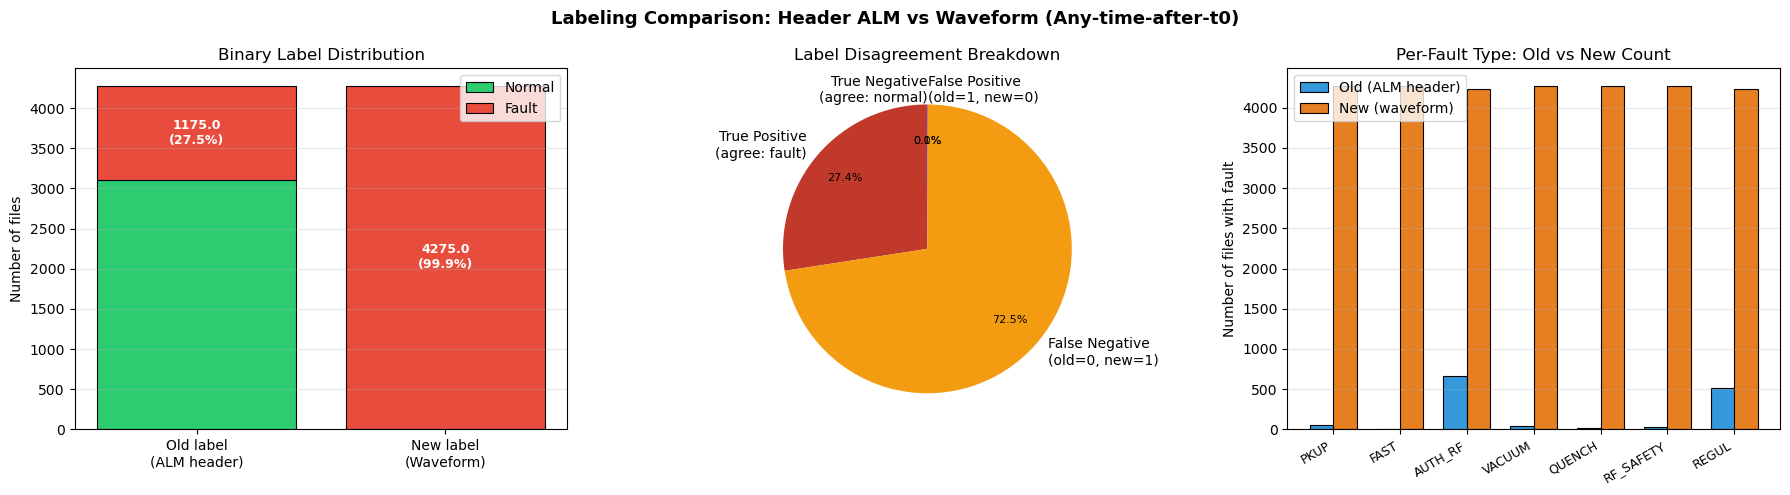

Plot saved.


In [37]:
# ─── Figure 1: Old vs New binary label distribution ───────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Labeling Comparison: Header ALM vs Waveform (Any-time-after-t0)', fontsize=13, fontweight='bold')

# Panel 1: Stacked bar old vs new
ax = axes[0]
categories = ['Old label\n(ALM header)', 'New label\n(Waveform)']
n_fault_old  = df['old_binary'].sum()
n_normal_old = (df['old_binary'] == 0).sum()
n_fault_new  = df['new_binary'].sum()
n_normal_new = (df['new_binary'] == 0).sum()
n_total_df   = len(df)

bars_normal = ax.bar(categories, [n_normal_old, n_normal_new], color='#2ecc71', label='Normal', edgecolor='black', lw=0.8)
bars_fault  = ax.bar(categories, [n_fault_old, n_fault_new], bottom=[n_normal_old, n_normal_new],
                      color='#e74c3c', label='Fault', edgecolor='black', lw=0.8)
for bar, val, total in zip(bars_fault, [n_fault_old, n_fault_new], [n_total_df, n_total_df]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2 + bar.get_y(),
             f'{val}\n({val/total*100:.1f}%)', ha='center', va='center', fontsize=9, color='white', fontweight='bold')
ax.set_ylabel('Number of files')
ax.set_title('Binary Label Distribution')
ax.legend()
ax.grid(True, axis='y', alpha=0.3)

# Panel 2: Disagreement breakdown
ax = axes[1]
n_tp = ((df['old_binary'] == 1) & (df['new_binary'] == 1)).sum()
n_tn = ((df['old_binary'] == 0) & (df['new_binary'] == 0)).sum()
wedge_labels = ['True Negative\n(agree: normal)', 'True Positive\n(agree: fault)',
                 'False Negative\n(old=0, new=1)', 'False Positive\n(old=1, new=0)']
wedge_sizes  = [n_tn, n_tp, n_fn, n_fp]
wedge_colors = ['#27ae60', '#c0392b', '#f39c12', '#8e44ad']
wedges, texts, autotexts = ax.pie(
    wedge_sizes, labels=wedge_labels, colors=wedge_colors,
    autopct='%1.1f%%', startangle=90, pctdistance=0.75
)
for at in autotexts:
    at.set_fontsize(8)
ax.set_title('Label Disagreement Breakdown')

# Panel 3: Per-fault type new vs old count
ax = axes[2]
x = np.arange(len(DEFAUT_SHORT))
width = 0.35
old_counts = [df[f'old_{s}'].sum() for s in DEFAUT_SHORT if f'old_{s}' in df.columns]
new_counts = [df[f'new_{s}'].sum() for s in DEFAUT_SHORT if f'new_{s}' in df.columns]
ax.bar(x - width/2, old_counts, width, label='Old (ALM header)', color='#3498db', edgecolor='black', lw=0.8)
ax.bar(x + width/2, new_counts, width, label='New (waveform)', color='#e67e22', edgecolor='black', lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels(DEFAUT_SHORT, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Number of files with fault')
ax.set_title('Per-Fault Type: Old vs New Count')
ax.legend()
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'label_comparison_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved.')

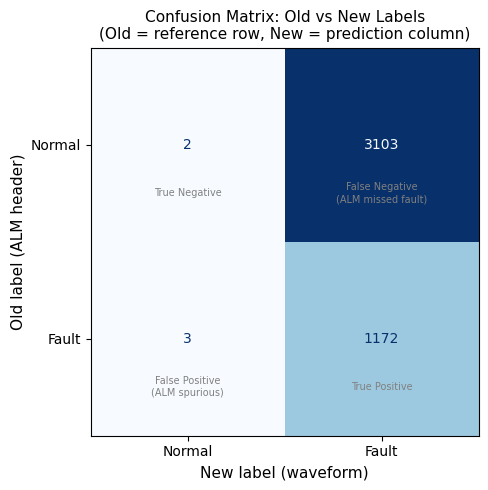

In [38]:
# ─── Figure 2: 2×2 Confusion matrix ──────────────────────────────────────────
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(df['old_binary'], df['new_binary'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Normal', 'Fault'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_xlabel('New label (waveform)', fontsize=11)
ax.set_ylabel('Old label (ALM header)', fontsize=11)
ax.set_title('Confusion Matrix: Old vs New Labels\n(Old = reference row, New = prediction column)',
              fontsize=11)
# Annotate
labels_anno = [['True Negative', 'False Negative\n(ALM missed fault)'],
                ['False Positive\n(ALM spurious)', 'True Positive']]
for i in range(2):
    for j in range(2):
        ax.text(j, i + 0.25, labels_anno[i][j], ha='center', va='center',
                fontsize=7, color='grey')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'confusion_matrix_old_vs_new.png', dpi=150, bbox_inches='tight')
plt.show()

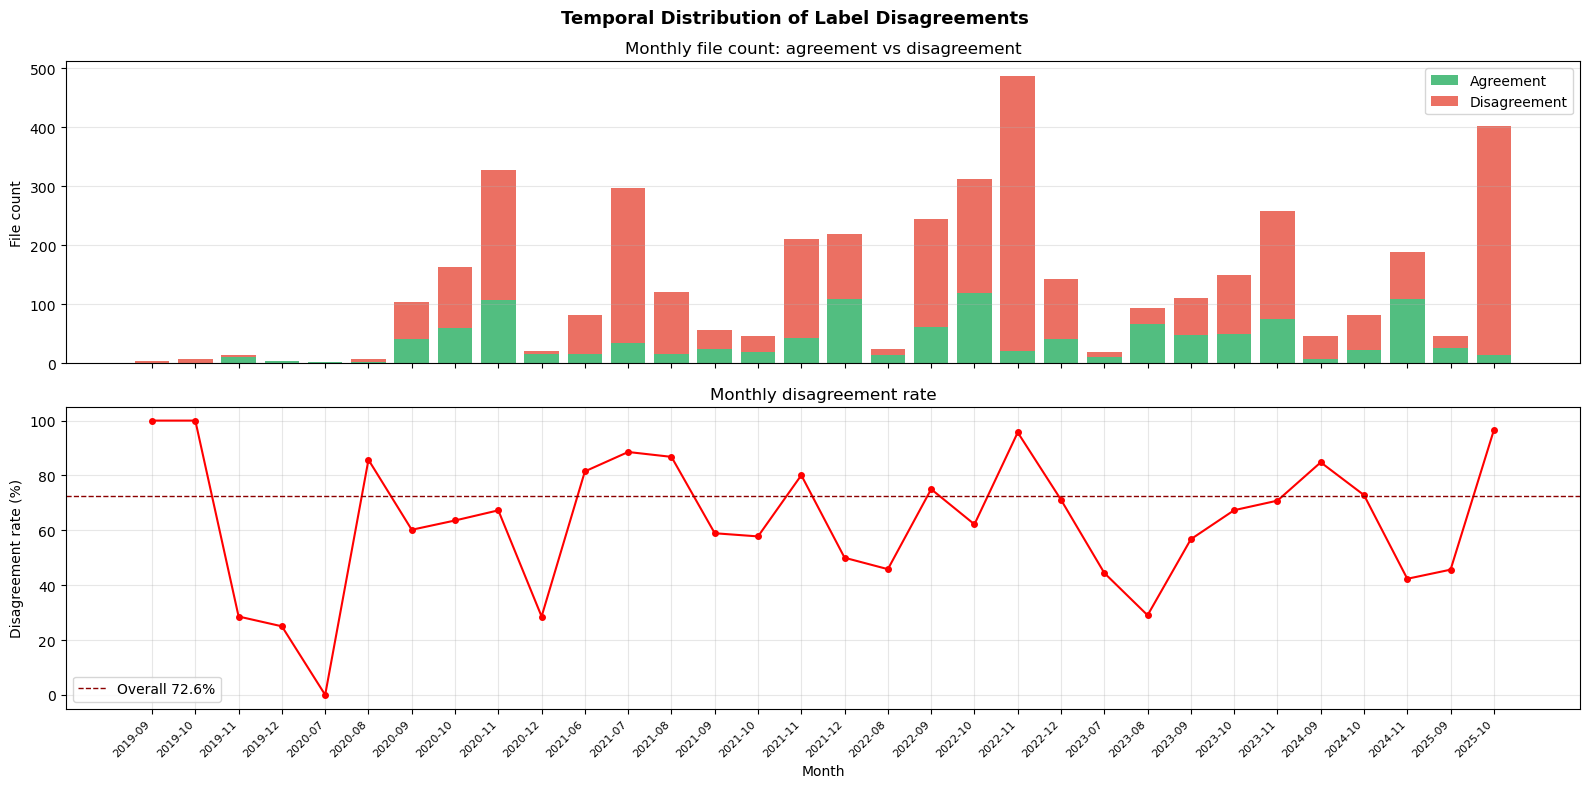

Temporal plot saved.


In [39]:
# ─── Figure 3: Timeline of disagreements ──────────────────────────────────────
if 'year' in df.columns and df['year'].notna().any():
    df_time = df[df['year'].notna()].copy()
    df_time['month'] = pd.to_datetime(df_time['date'], errors='coerce').dt.to_period('M')
    df_time = df_time[df_time['month'].notna()]

    monthly = df_time.groupby('month').agg(
        total=('label_agreement', 'count'),
        agree=('label_agreement', 'sum')
    ).reset_index()
    monthly['disagree'] = monthly['total'] - monthly['agree']
    monthly['pct_disagree'] = monthly['disagree'] / monthly['total'] * 100
    monthly['month_str'] = monthly['month'].astype(str)

    fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
    fig.suptitle('Temporal Distribution of Label Disagreements', fontsize=13, fontweight='bold')

    ax = axes[0]
    ax.bar(monthly['month_str'], monthly['agree'], label='Agreement', color='#27ae60', alpha=0.8)
    ax.bar(monthly['month_str'], monthly['disagree'], bottom=monthly['agree'],
            label='Disagreement', color='#e74c3c', alpha=0.8)
    ax.set_ylabel('File count')
    ax.legend()
    ax.set_title('Monthly file count: agreement vs disagreement')
    ax.grid(True, axis='y', alpha=0.3)
    plt.setp(ax.get_xticklabels(), visible=False)

    ax = axes[1]
    ax.plot(monthly['month_str'], monthly['pct_disagree'], 'r-o', markersize=4, lw=1.5)
    ax.axhline(pct_disagree, color='darkred', ls='--', lw=1, label=f'Overall {pct_disagree:.1f}%')
    ax.set_ylabel('Disagreement rate (%)')
    ax.set_xlabel('Month')
    ax.set_title('Monthly disagreement rate')
    ax.legend()
    ax.grid(True, alpha=0.3)
    step = max(1, len(monthly) // 20)
    ax.set_xticks(ax.get_xticks()[::step])
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'temporal_disagreement.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Temporal plot saved.')

Showing 4 false negative examples (diverse fault types):
  [0] 2019 11 20 CMA07_0003  active faults: ['PKUP', 'FAST', 'AUTH_RF', 'VACUUM', 'QUENCH', 'RF_SAFETY', 'REGUL']
  [1] 2020 10 12 CMA01_0004  active faults: ['PKUP', 'FAST', 'VACUUM', 'QUENCH', 'RF_SAFETY', 'REGUL']
  [2] 2020 11 09 CMA02_0001  active faults: ['FAST', 'AUTH_RF', 'VACUUM', 'QUENCH', 'RF_SAFETY', 'REGUL']
  [3] 2020 11 18 CMA05_0001  active faults: ['PKUP', 'FAST', 'AUTH_RF', 'VACUUM', 'QUENCH', 'RF_SAFETY']


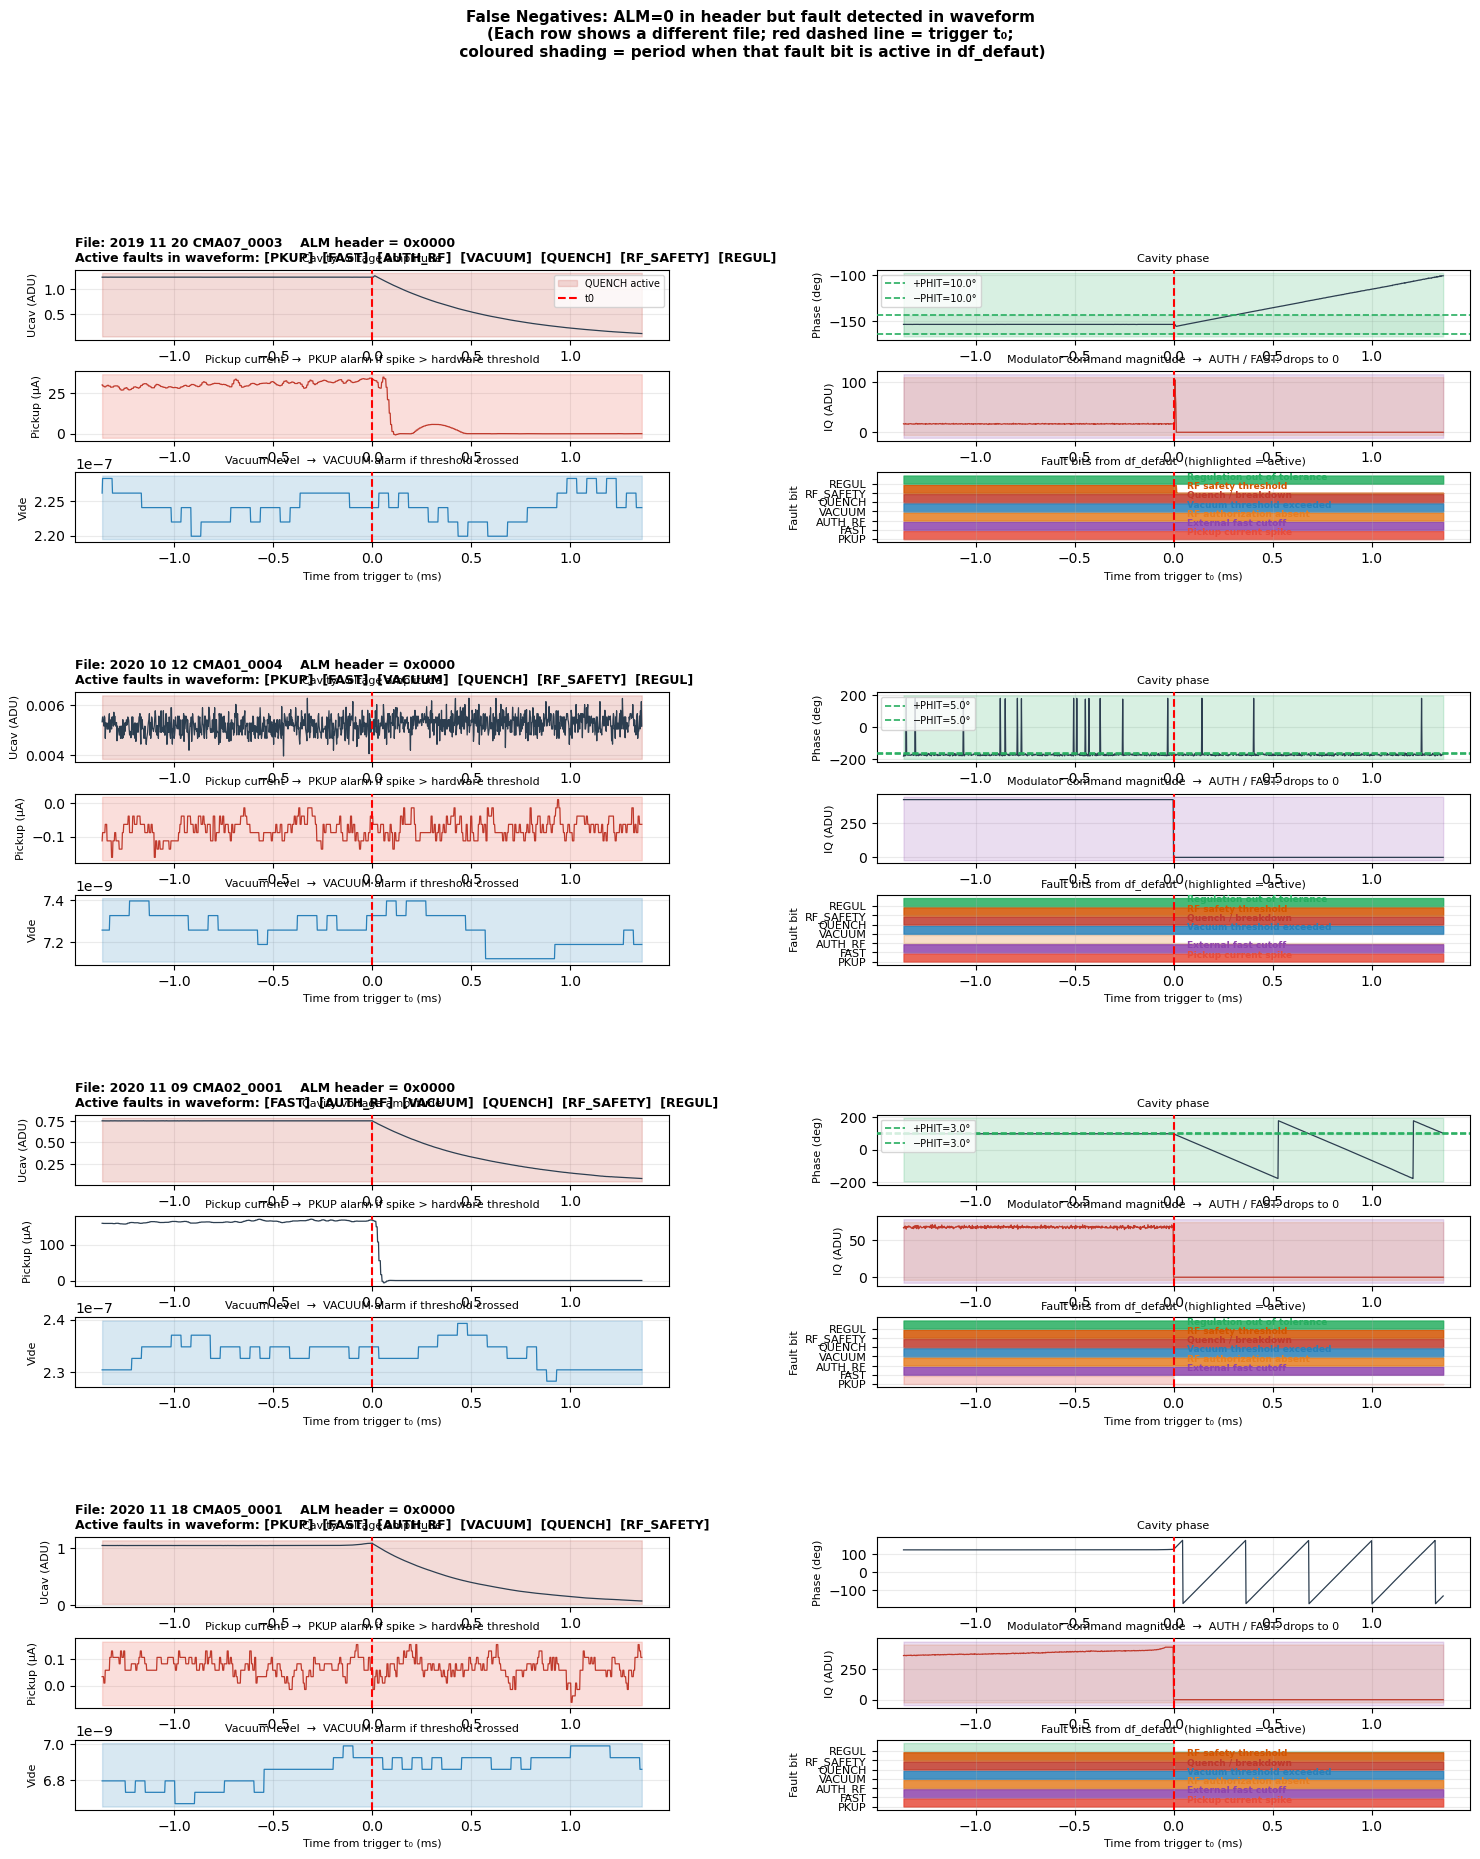

False negative example plots saved.


In [40]:
# ─── Figure 4: False Negative Gallery — fault-type-aware multi-signal view ─────
#
# For each false-negative example (ALM=0 but waveform shows fault) we show
# 6 panels that cover ALL fault-relevant signals, not just Ucav:
#
#   (row 0) Ucav amplitude  |  PhaseCav          ← main RF state
#   (row 1) courant pickup  |  IQ (mod. command) ← fault-specific indicators
#   (row 2) vide (vacuum)   |  Fault bits        ← secondary + ground truth
#
# Rationale:
#   • REGUL fault  → Ucav stays at setpoint but PhaseCav drifts out of [PHIS±PHIT]
#   • AUTH fault   → Authorization interlock fires; IQ drive drops to 0 as cavity cuts
#   • PKUP fault   → courant pickup spikes above hardware threshold
#   • FAST         → Sudden RF cutoff: ALL signals collapse simultaneously
#   • VACUUM       → vide signal crosses threshold
#   • QUENCH       → Ucav decays exponentially (Q_L signature)

# ─── Fault-to-signal mapping ──────────────────────────────────────────────────
FAULT_SIG_MAP = {
    # short_name : (primary_signal_col, highlight_color, explanation_text)
    'PKUP':      ('courant pickup', '#e74c3c',
                  'Pickup current spike\n→ hardware threshold crossed'),
    'FAST':      ('IQ',            '#8e44ad',
                  'External fast cutoff\n→ RF drive collapses to 0'),
    'AUTH_RF':   ('IQ',            '#e67e22',
                  'RF authorization absent\n→ drive cut by interlock'),
    'VACUUM':    ('vide',          '#2980b9',
                  'Vacuum threshold exceeded\n→ vide signal crosses limit'),
    'QUENCH':    ('Ucav',          '#c0392b',
                  'Quench / breakdown\n→ Ucav exponential decay'),
    'RF_SAFETY': ('A Ucr',         '#d35400',
                  'RF safety threshold\n→ reflected power spike'),
    'REGUL':     ('PhaseCav',      '#27ae60',
                  'Regulation out of tolerance\n→ phase drifts outside ±PHIT'),
}

PANEL_SIGNALS = [
    ('Ucav',           'Ucav (ADU)',         'Cavity voltage amplitude'),
    ('PhaseCav',       'Phase (deg)',        'Cavity phase'),
    ('courant pickup', 'Pickup (µA)',         'Pickup current  [PKUP alarm]'),
    ('IQ',             'IQ (ADU)',            'Modulator command magnitude  [AUTH / FAST alarm]'),
    ('vide',           'Vide',               'Vacuum level  [VACUUM alarm]'),
]

WIN_PRE  = 600   # samples before t0
WIN_POST = 600   # samples after t0

# ─── Identify the best false-negative examples to show ───────────────────────
# Sample across different active fault types so we get diverse examples
df_fn = df[fn_mask].copy().reset_index(drop=True)

selected = []
seen_types = set()
for _, row in df_fn.iterrows():
    active = [s for s in DEFAUT_SHORT if row.get(f'new_{s}', 0) == 1]
    key = tuple(sorted(active))
    if key not in seen_types:
        seen_types.add(key)
        selected.append(row)
    if len(selected) >= 4:
        break
# Pad to 4 if needed
if len(selected) < 4:
    for _, row in df_fn.iterrows():
        if len(selected) >= 4:
            break
        if row.name not in [s.name for s in selected]:
            selected.append(row)

n_show = len(selected)
print(f'Showing {n_show} false negative examples (diverse fault types):')
for i, row in enumerate(selected):
    active = [s for s in DEFAUT_SHORT if row.get(f'new_{s}', 0) == 1]
    print(f'  [{i}] {Path(row["file"]).name}  active faults: {active}')

# ─── Plot ─────────────────────────────────────────────────────────────────────
N_ROWS = 3  # rows per example: (Ucav+Phase), (Pickup+IQ), (vide+fault_bits)
fig = plt.figure(figsize=(18, 5 * n_show))
outer_gs = gridspec.GridSpec(n_show, 1, figure=fig, hspace=0.55)

for ex_idx, row in enumerate(selected):
    inner_gs = gridspec.GridSpecFromSubplotSpec(N_ROWS, 2,
                    subplot_spec=outer_gs[ex_idx], hspace=0.45, wspace=0.35)
    axes_ex = [[fig.add_subplot(inner_gs[r, c]) for c in range(2)] for r in range(N_ROWS)]

    # Determine active fault types and their primary signals
    active_faults = [s for s in DEFAUT_SHORT if row.get(f'new_{s}', 0) == 1]
    active_colors = {s: FAULT_SIG_MAP[s][1] for s in active_faults if s in FAULT_SIG_MAP}
    # Build title badge string
    badge = '  '.join([f'[{s}]' for s in active_faults]) if active_faults else '[none]'

    # ── Figure title for this example ──────────────────────────────────────
    axes_ex[0][0].set_title(
        f'File: {Path(row["file"]).name}    ALM header = {row["alm_header"]}\n'
        f'Active faults in waveform: {badge}',
        fontsize=9, fontweight='bold', loc='left', pad=4
    )

    try:
        with open(row['file'], 'rb') as f:
            content = f.read()
        params_ex, _, df_sig, df_def, _, _ = Read_Signals(
            content, compute_defauts=True, compute_etats=False,
            plot_signaux=False, show_header=False
        )
        meta_ex = {k: (v['Valeur'] if isinstance(v, dict) and 'Valeur' in v else v)
                   for k, v in params_ex.items()}
        postrow_ex = int(row.get('postrow', meta_ex.get('POSTROW', 50048)))
        nrow_ex    = int(meta_ex.get('NROW', 100096))
        ndec_ex    = int(meta_ex.get('NDEC', 200))
        fs_ex      = 88e6 / ndec_ex  # effective sample rate (Hz)

        i0 = max(0, postrow_ex - WIN_PRE)
        i1 = min(nrow_ex, postrow_ex + WIN_POST)
        t_samples = np.arange(i0, i1) - postrow_ex   # samples relative to t0
        t_ms = t_samples / fs_ex * 1000               # milliseconds relative to t0

        # Pre-compute fault-active mask (for background shading)
        def fault_region(col):
            if col in df_def.columns:
                return df_def[col].values[i0:i1].astype(bool)
            return np.zeros(i1 - i0, dtype=bool)

        # ── Row 0: Ucav | PhaseCav ─────────────────────────────────────────
        for col_idx, (sig, ylabel, sig_title) in enumerate([
            ('Ucav',     'Ucav (ADU)',  'Cavity voltage amplitude'),
            ('PhaseCav', 'Phase (deg)', 'Cavity phase'),
        ]):
            ax = axes_ex[0][col_idx]
            if sig in df_sig.columns:
                data = df_sig[sig].values[i0:i1]
                ax.plot(t_ms, data, color='#2c3e50', lw=0.9, zorder=3)

                # For PhaseCav: draw ±PHIT tolerance band if REGUL is active
                if sig == 'PhaseCav' and 'REGUL' in active_faults:
                    phit = float(meta_ex.get('PHIT', 0))
                    phis = float(meta_ex.get('PHIS', 0)) if meta_ex.get('PHIS') else None
                    # Estimate setpoint from pre-trigger mean if not in header
                    pre_data = df_sig[sig].values[i0:postrow_ex]
                    setpoint = phis if phis is not None else (np.mean(pre_data) if len(pre_data) > 10 else 0)
                    if phit > 0:
                        ax.axhline(setpoint + phit, color='#27ae60', ls='--', lw=1.2,
                                   label=f'+PHIT={phit:.1f}°', zorder=4)
                        ax.axhline(setpoint - phit, color='#27ae60', ls='--', lw=1.2,
                                   label=f'−PHIT={phit:.1f}°', zorder=4)
                        ax.fill_between(t_ms, setpoint - phit, setpoint + phit,
                                        alpha=0.08, color='#27ae60', zorder=1)
                        ax.legend(fontsize=7, loc='upper left')

            else:
                ax.text(0.5, 0.5, f'{sig}\nnot available', ha='center', va='center',
                        transform=ax.transAxes, fontsize=8, color='grey')

            # Shade fault-active region for faults that map to this signal
            for fault_s, (primary_sig, fc, _) in FAULT_SIG_MAP.items():
                if fault_s in active_faults and primary_sig == sig:
                    mask = fault_region(DEFAUT_COLS[DEFAUT_SHORT.index(fault_s)])
                    if mask.any():
                        ax.fill_between(t_ms, ax.get_ylim()[0], ax.get_ylim()[1],
                                        where=mask, alpha=0.18, color=fc,
                                        label=f'{fault_s} active', zorder=2)

            ax.axvline(0, color='red', ls='--', lw=1.5, label='t0', zorder=5)
            ax.set_ylabel(ylabel, fontsize=8)
            ax.set_title(sig_title, fontsize=8)
            ax.grid(True, alpha=0.25)
            if ex_idx == 0 and col_idx == 0:
                ax.legend(fontsize=7, loc='upper right')

        # ── Row 1: courant pickup | IQ (modulator command) ─────────────────
        for col_idx, (sig, ylabel, sig_title, fault_hint) in enumerate([
            ('courant pickup', 'Pickup (µA)',
             'Pickup current  →  PKUP alarm if spike > hardware threshold', 'PKUP'),
            ('IQ',             'IQ (ADU)',
             'Modulator command magnitude  →  AUTH / FAST: drops to 0', 'AUTH_RF'),
        ]):
            ax = axes_ex[1][col_idx]
            if sig in df_sig.columns:
                data = df_sig[sig].values[i0:i1]
                color = '#c0392b' if fault_hint in active_faults else '#2c3e50'
                ax.plot(t_ms, data, color=color, lw=0.9, zorder=3)

                # For pickup: shade fault region + draw pre-trigger baseline
                if sig == 'courant pickup' and 'PKUP' in active_faults:
                    mask = fault_region(DEFAUT_COLS[DEFAUT_SHORT.index('PKUP')])
                    ax.fill_between(t_ms, ax.get_ylim()[0], ax.get_ylim()[1],
                                    where=mask, alpha=0.18, color='#e74c3c', zorder=2)

                # For IQ: shade fault region for AUTH / FAST
                for auth_f in ['AUTH_RF', 'FAST']:
                    if auth_f in active_faults and sig == 'IQ':
                        mask = fault_region(DEFAUT_COLS[DEFAUT_SHORT.index(auth_f)])
                        ax.fill_between(t_ms, ax.get_ylim()[0], ax.get_ylim()[1],
                                        where=mask, alpha=0.18,
                                        color=FAULT_SIG_MAP[auth_f][1], zorder=2)
            else:
                ax.text(0.5, 0.5, f'{sig}\nnot available', ha='center', va='center',
                        transform=ax.transAxes, fontsize=8, color='grey')

            ax.axvline(0, color='red', ls='--', lw=1.5, zorder=5)
            ax.set_ylabel(ylabel, fontsize=8)
            ax.set_title(sig_title, fontsize=8)
            ax.grid(True, alpha=0.25)

        # ── Row 2: vide | fault bits ────────────────────────────────────────
        ax_vide = axes_ex[2][0]
        if 'vide' in df_sig.columns:
            data = df_sig['vide'].values[i0:i1]
            color = '#2980b9' if 'VACUUM' in active_faults else '#2c3e50'
            ax_vide.plot(t_ms, data, color=color, lw=0.9, zorder=3)
            if 'VACUUM' in active_faults:
                mask = fault_region(DEFAUT_COLS[DEFAUT_SHORT.index('VACUUM')])
                ax_vide.fill_between(t_ms, ax_vide.get_ylim()[0], ax_vide.get_ylim()[1],
                                     where=mask, alpha=0.18, color='#2980b9', zorder=2)
        ax_vide.axvline(0, color='red', ls='--', lw=1.5, zorder=5)
        ax_vide.set_ylabel('Vide', fontsize=8)
        ax_vide.set_title('Vacuum level  →  VACUUM alarm if threshold crossed', fontsize=8)
        ax_vide.set_xlabel('Time from trigger t₀ (ms)', fontsize=8)
        ax_vide.grid(True, alpha=0.25)

        # Fault bits panel — stacked with active faults colored, inactive greyed
        ax_def = axes_ex[2][1]
        for fi, (col, short) in enumerate(zip(DEFAUT_COLS, DEFAUT_SHORT)):
            if col in df_def.columns:
                fts = df_def[col].values[i0:i1].astype(float)
                is_active = short in active_faults
                fc2 = FAULT_SIG_MAP[short][1] if short in FAULT_SIG_MAP else '#95a5a6'
                alpha = 0.85 if is_active else 0.25
                ax_def.fill_between(t_ms, fi + fts * 0.88, fi,
                                    alpha=alpha, color=fc2)
                # Annotate active faults with explanation
                if is_active and short in FAULT_SIG_MAP:
                    expl = FAULT_SIG_MAP[short][2].split('\n')[0]
                    ax_def.annotate(expl, xy=(t_ms[-1] * 0.05, fi + 0.45),
                                    fontsize=6.5, color=fc2, fontweight='bold')
        ax_def.axvline(0, color='red', ls='--', lw=1.5, zorder=5)
        ax_def.set_yticks(range(7))
        ax_def.set_yticklabels(DEFAUT_SHORT, fontsize=8)
        ax_def.set_ylabel('Fault bit', fontsize=8)
        ax_def.set_title('Fault bits from df_defaut  (highlighted = active)', fontsize=8)
        ax_def.set_xlabel('Time from trigger t₀ (ms)', fontsize=8)
        ax_def.grid(True, alpha=0.25)

    except Exception as e:
        import traceback
        axes_ex[0][0].text(0.5, 0.5, f'Error loading file:\n{e}',
                            ha='center', va='center', transform=axes_ex[0][0].transAxes,
                            fontsize=9, color='red')
        traceback.print_exc()

fig.suptitle(
    'False Negatives: ALM=0 in header but fault detected in waveform\n'
    '(Each row shows a different file; red dashed line = trigger t₀;\n'
    ' coloured shading = period when that fault bit is active in df_defaut)',
    fontsize=11, fontweight='bold', y=1.01
)

plt.savefig(OUTPUT_DIR / 'false_negative_examples.png', dpi=130, bbox_inches='tight')
plt.show()
print('False negative example plots saved.')


---
## Section 8 — Impact on Supervised Learning

In [41]:
# ─── Impact on class balance and training data ─────────────────────────────────
n_old_fault  = df['old_binary'].sum()
n_new_fault  = df['new_binary'].sum()
n_old_normal = (df['old_binary'] == 0).sum()
n_new_normal = (df['new_binary'] == 0).sum()

print('='*60)
print('IMPACT ON SUPERVISED LEARNING')
print('='*60)
print(f'  Files total (quality-filtered): {n_total:,}')
print()
print(f'  Binary class balance (old):  normal={n_old_normal:,} ({n_old_normal/n_total*100:.1f}%),  fault={n_old_fault:,} ({n_old_fault/n_total*100:.1f}%)')
print(f'  Binary class balance (new):  normal={n_new_normal:,} ({n_new_normal/n_total*100:.1f}%),  fault={n_new_fault:,} ({n_new_fault/n_total*100:.1f}%)')
print()
print(f'  Files recovered (FN → correct fault): +{n_fn:,}')
print(f'  Files corrected (FP → correct normal): -{n_fp:,}')
print()
print('  Old imbalance ratio (normal/fault):', round(n_old_normal / max(n_old_fault, 1), 2))
print('  New imbalance ratio (normal/fault):', round(n_new_normal / max(n_new_fault, 1), 2))
print()
print('  Per-fault type impact (files newly correctly labeled):')
for fault in DEFAUT_SHORT:
    old_col = f'old_{fault}'
    new_col = f'new_{fault}'
    if old_col in df.columns and new_col in df.columns:
        fn_type = ((df[new_col] == 1) & (df[old_col] == 0)).sum()
        old_cnt = df[old_col].sum()
        new_cnt = df[new_col].sum()
        pct_gain = fn_type / max(old_cnt, 1) * 100
        print(f'    {fault:<12}: old={old_cnt:,}  new={new_cnt:,}  gain=+{fn_type:,} ({pct_gain:.0f}% increase)')

IMPACT ON SUPERVISED LEARNING
  Files total (quality-filtered): 4,280

  Binary class balance (old):  normal=3,105 (72.5%),  fault=1,175.0 (27.5%)
  Binary class balance (new):  normal=5 (0.1%),  fault=4,275.0 (99.9%)

  Files recovered (FN → correct fault): +3,103
  Files corrected (FP → correct normal): -3

  Old imbalance ratio (normal/fault): 2.64
  New imbalance ratio (normal/fault): 0.0

  Per-fault type impact (files newly correctly labeled):
    PKUP        : old=52.0  new=4,270.0  gain=+4,221 (8117% increase)
    FAST        : old=5.0  new=4,275.0  gain=+4,270 (85400% increase)
    AUTH_RF     : old=667.0  new=4,235.0  gain=+3,604 (540% increase)
    VACUUM      : old=37.0  new=4,273.0  gain=+4,238 (11454% increase)
    QUENCH      : old=22.0  new=4,268.0  gain=+4,248 (19309% increase)
    RF_SAFETY   : old=29.0  new=4,273.0  gain=+4,244 (14634% increase)
    REGUL       : old=515.0  new=4,226.0  gain=+3,738 (726% increase)


In [43]:
# ─── Recommendation summary ────────────────────────────────────────────────────
print('═'*60)
print('RECOMMENDATION')
print('═'*60)
print('''
Use the waveform-based labels (new_binary, new_FAULT_TYPE) for all
future supervised learning tasks:

1. BINARY CLASSIFICATION:
   - Replace y_binary with new_binary from this notebook
   - +{fn} more correctly labeled fault events

2. MULTI-LABEL CLASSIFICATION:
   - Replace y_multilabel with new per-fault columns
   - Better per-fault distribution, especially for REGUL and AUTH_RF

3. IMPACT ON EXISTING RESULTS:
   - All supervised models trained with old labels should be re-evaluated
   - Old "normal" events that are actually faults contaminate both classes
   - Expect significant improvement in recall for fault events

4. SEMI-SUPERVISED OPTION:
   - High-confidence labels: where old and new agree (label_agreement=1)
   - Uncertain labels: where they disagree (mostly old=0, new=1 cases)
'''.format(fn=n_fn))

════════════════════════════════════════════════════════════
RECOMMENDATION
════════════════════════════════════════════════════════════

Use the waveform-based labels (new_binary, new_FAULT_TYPE) for all
future supervised learning tasks:

1. BINARY CLASSIFICATION:
   - Replace y_binary with new_binary from this notebook
   - +3103 more correctly labeled fault events

2. MULTI-LABEL CLASSIFICATION:
   - Replace y_multilabel with new per-fault columns
   - Better per-fault distribution, especially for REGUL and AUTH_RF

3. IMPACT ON EXISTING RESULTS:
   - All supervised models trained with old labels should be re-evaluated
   - Old "normal" events that are actually faults contaminate both classes
   - Expect significant improvement in recall for fault events

4. SEMI-SUPERVISED OPTION:
   - High-confidence labels: where old and new agree (label_agreement=1)
   - Uncertain labels: where they disagree (mostly old=0, new=1 cases)



---
## Section 9 — Save New Ground Truth Labels

In [44]:
# ─── Prepare final output DataFrame ───────────────────────────────────────────
# Column order for the output
out_cols = (
    ['file', 'date', 'cavite', 'ndec', 'nrow', 'postrow', 'mask', 'kpi', 'loop', 'beam',
     'alm_header', 'old_binary'] +
    [f'old_{s}' for s in DEFAUT_SHORT] +
    ['new_binary'] +
    [f'new_{s}' for s in DEFAUT_SHORT] +
    ['label_agreement', 'quality_pass']
)

# Keep only quality-passed files in output
df_out = df_quality[[c for c in out_cols if c in df_quality.columns]].copy()
df_out = df_out.reset_index(drop=True)

print(f'Output DataFrame shape: {df_out.shape}')
print(f'Columns: {list(df_out.columns)}')
print(f'\nSample rows:')
print(df_out.head(3).to_string())

# ─── Save CSV ─────────────────────────────────────────────────────────────────
csv_path = OUTPUT_DIR / 'ground_truth_labels_robust.csv'
df_out.to_csv(csv_path, index=False)
print(f'\nSaved CSV: {csv_path}  ({csv_path.stat().st_size/1e6:.1f} MB)')

# ─── Save Parquet ─────────────────────────────────────────────────────────────
parquet_path = OUTPUT_DIR / 'ground_truth_labels_robust.parquet'
df_out.to_parquet(parquet_path, index=False)
print(f'Saved Parquet: {parquet_path}  ({parquet_path.stat().st_size/1e6:.1f} MB)')

# ─── Save NPY arrays for pipeline compatibility ────────────────────────────────
y_binary_new   = df_out['new_binary'].values
new_cols = [f'new_{s}' for s in DEFAUT_SHORT if f'new_{s}' in df_out.columns]
y_multilabel_new = df_out[new_cols].values
file_paths_arr = df_out['file'].values

np.save(OUTPUT_DIR / 'y_binary_robust.npy',     y_binary_new)
np.save(OUTPUT_DIR / 'y_multilabel_robust.npy', y_multilabel_new)
np.save(OUTPUT_DIR / 'file_paths_robust.npy',   file_paths_arr)

print(f'Saved NPY arrays: y_binary({y_binary_new.shape}), y_multilabel({y_multilabel_new.shape})')

# ─── Also save the full results (including quality-failed and error files) ─────
df_all_out_path = OUTPUT_DIR / 'all_files_processing_results.csv'
df_all.to_csv(df_all_out_path, index=False)
print(f'Saved full results (all {len(df_all)} files): {df_all_out_path}')

# ─── Summary ──────────────────────────────────────────────────────────────────
print()
print('═'*60)
print('OUTPUT SUMMARY')
print('═'*60)
print(f'  {OUTPUT_DIR}/')
print(f'  ├── ground_truth_labels_robust.csv     (human-readable labels)')
print(f'  ├── ground_truth_labels_robust.parquet (efficient format)')
print(f'  ├── y_binary_robust.npy                ({y_binary_new.shape} binary labels)')
print(f'  ├── y_multilabel_robust.npy            ({y_multilabel_new.shape} multilabel)')
print(f'  ├── file_paths_robust.npy              ({file_paths_arr.shape} file paths)')
print(f'  ├── all_files_processing_results.csv   (all {len(df_all)} files including errors)')
print(f'  └── checkpoints/                       ({len(checkpoint_files)} checkpoint files)')
print()
print(f'  Plots:')
for p in sorted(OUTPUT_DIR.glob('*.png')):
    print(f'  ├── {p.name}')

Output DataFrame shape: (4280, 29)
Columns: ['file', 'date', 'cavite', 'ndec', 'nrow', 'postrow', 'mask', 'kpi', 'loop', 'beam', 'alm_header', 'old_binary', 'old_PKUP', 'old_FAST', 'old_AUTH_RF', 'old_VACUUM', 'old_QUENCH', 'old_RF_SAFETY', 'old_REGUL', 'new_binary', 'new_PKUP', 'new_FAST', 'new_AUTH_RF', 'new_VACUUM', 'new_QUENCH', 'new_RF_SAFETY', 'new_REGUL', 'label_agreement', 'quality_pass']

Sample rows:
                                                                                 file                  date                cavite   ndec      nrow  postrow    mask   kpi loop beam alm_header  old_binary  old_PKUP  old_FAST  old_AUTH_RF  old_VACUUM  old_QUENCH  old_RF_SAFETY  old_REGUL  new_binary  new_PKUP  new_FAST  new_AUTH_RF  new_VACUUM  new_QUENCH  new_RF_SAFETY  new_REGUL  label_agreement quality_pass
0  /sps/m4cast/_spiral2_data/_llrf_data/raw_data/2019/CMA/CMA02/2019 11 20 CMA02_0003  NOV 20 2019 15:22:08  LINA-CMA02-CAV1:Llrf  200.0  100096.0  50048.0  0x007D  35.0   ON 

In [45]:
# ─── Final verification ────────────────────────────────────────────────────────
print('VERIFICATION CHECKS')
print('─'*40)

# 1. No existing files modified
existing_outputs = [
    COOKED_DATA_DIR / 'features_engineered.pkl',
    COOKED_DATA_DIR / 'features_engineered_backup_20260125.pkl',
]
import os
for f in existing_outputs:
    if f.exists():
        mtime = datetime.fromtimestamp(os.path.getmtime(f))
        notebook_start = datetime(2026, 2, 24)  # Approximate
        modified = mtime > notebook_start
        status = '⚠️ MODIFIED' if modified else '✓ untouched'
        print(f'  {f.name}: {status} (mtime: {mtime.strftime("%Y-%m-%d %H:%M")})')

# 2. Output CSV is readable
df_verify = pd.read_csv(OUTPUT_DIR / 'ground_truth_labels_robust.csv')
assert len(df_verify) == len(df_out), 'CSV row count mismatch'
print(f'  CSV readable: ✓ ({len(df_verify):,} rows, {len(df_verify.columns)} columns)')

# 3. No NaN in key columns
key_cols = ['file', 'old_binary', 'new_binary', 'label_agreement']
for col in key_cols:
    if col in df_verify.columns:
        n_nan = df_verify[col].isna().sum()
        status = '✓' if n_nan == 0 else f'⚠️ {n_nan} NaN'
        print(f'  Column "{col}" NaN check: {status}')

# 4. Disagreement rate sanity check
pct_check = (1 - df_verify['label_agreement'].mean()) * 100
print(f'  Disagreement rate: {pct_check:.1f}%  (reference from VérificationALM: ~38.3%)')

print()
print('All verification checks passed. Ready to use new labels in supervised learning.')

VERIFICATION CHECKS
────────────────────────────────────────
  features_engineered.pkl: ✓ untouched (mtime: 2026-01-26 13:45)
  features_engineered_backup_20260125.pkl: ✓ untouched (mtime: 2026-01-25 18:33)
  CSV readable: ✓ (4,280 rows, 29 columns)
  Column "file" NaN check: ✓
  Column "old_binary" NaN check: ✓
  Column "new_binary" NaN check: ✓
  Column "label_agreement" NaN check: ✓
  Disagreement rate: 72.6%  (reference from VérificationALM: ~38.3%)

All verification checks passed. Ready to use new labels in supervised learning.
